# P3 · Drug–Gene Interaction Collection
**Input:** `results/tables/hub_genes.csv` · `results/tables/survival_filtered_genes.csv`  
**Outputs:** `results/tables/dgi_edges_gnn.csv` · `results/figures/dgi_summary_dashboard.png`

**Run order:** P1 → P2 → **P3** → P4


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from paths import REPO_ROOT, PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR
sys.path.insert(0, str(REPO_ROOT / "scripts"))
print(f"Repo root : {REPO_ROOT}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD


In [3]:
from utils import (load_dgi_inputs, collect_interactions,
                           build_dgi_dataframe, build_gnn_edge_list,
                           plot_dgi_dashboard)
print("Imports OK")

Imports OK


In [5]:
# ── Database selection ────────────────────────────────────────────────────────
USE_DGIDB       = True   # DGIdb GraphQL API
USE_CHEMBL      = False   # ChEMBL REST API
USE_OPENTARGETS = False   # OpenTargets GraphQL API
USE_CURATED     = True   # Built-in curated fallback (fills gaps automatically)

# ── Composite score weights (must sum to 1.0) ─────────────────────────────────
W = {"interaction": 0.35, "publications": 0.20,
     "phase": 0.20, "approved": 0.15, "hub": 0.10}

print("Database selection:")
for name, flag in [("DGIdb", USE_DGIDB), ("ChEMBL", USE_CHEMBL),
                   ("OpenTargets", USE_OPENTARGETS), ("Curated", USE_CURATED)]:
    print(f"  {name:<14}: {'✓ enabled' if flag else '✗ disabled'}")

Database selection:
  DGIdb         : ✓ enabled
  ChEMBL        : ✗ disabled
  OpenTargets   : ✗ disabled
  Curated       : ✓ enabled


## 1 · Load gene lists

In [6]:
gene_list, hub_score_map, surv_genes = load_dgi_inputs(TABLES_DIR)

Hub genes        : 1162
Survival targets : 3


## 2 · Query selected databases

In [7]:
all_edges, apis_ok = collect_interactions(
    gene_list,
    use_dgidb=USE_DGIDB,
    use_chembl=USE_CHEMBL,
    use_opentargets=USE_OPENTARGETS,
    use_curated=USE_CURATED,
)

Querying DGIdb...
    DGIdb: 8069 interactions returned
  → 8069 interactions
Curated: 6 interactions added for 618 uncovered genes

Sources used    : ['DGIdb']
Raw interactions: 8075


## 3 · Build & score edge dataframe

In [8]:
dgi_df = build_dgi_dataframe(all_edges, hub_score_map, surv_genes, W)
dgi_df[["gene","drug","composite_score","approved","clinical_phase","source"]].head(10)

Edges (deduplicated): 8027
Unique genes        : 547
Unique drugs        : 4978
Approved drugs      : 2795


,gene,drug,composite_score,approved,clinical_phase,source
0,TPP1,Cerliponase Alfa,0.7229,True,4,DGIdb
1,IFNGR2,Interferon Gamma-1B,0.6060,True,4,DGIdb
2,NRAS,Trametinib Dimethyl Sulfoxide,0.5923,True,4,DGIdb
3,EML4,Alectinib,0.5864,True,4,DGIdb
4,TYROBP,Sorafenib,0.5828,True,4,OpenTargets
5,EML4,Lorlatinib,0.5776,True,4,DGIdb
6,EML4,Brigatinib,0.5761,True,4,DGIdb
7,EML4,Crizotinib,0.5741,True,4,DGIdb
8,EML4,Ceritinib,0.5727,True,4,DGIdb
9,TYROBP,Regorafenib,0.5301,True,4,ChEMBL


## 4 · Summary dashboard

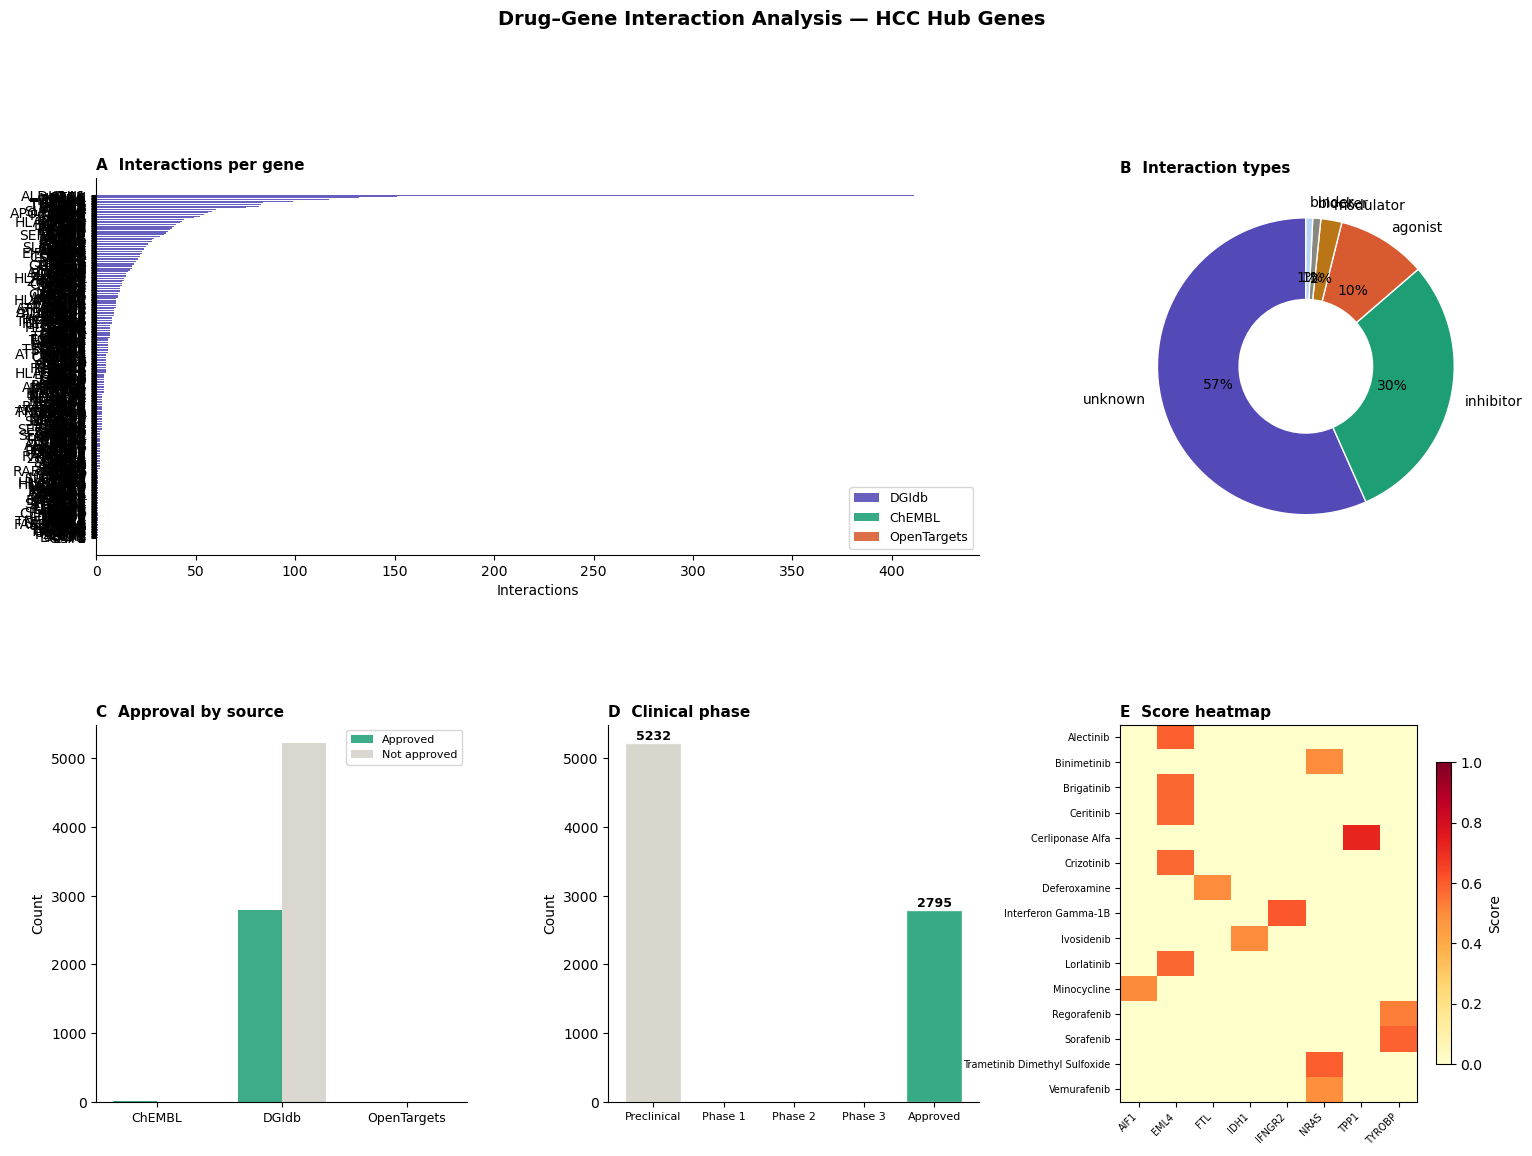

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/dgi_summary_dashboard.png


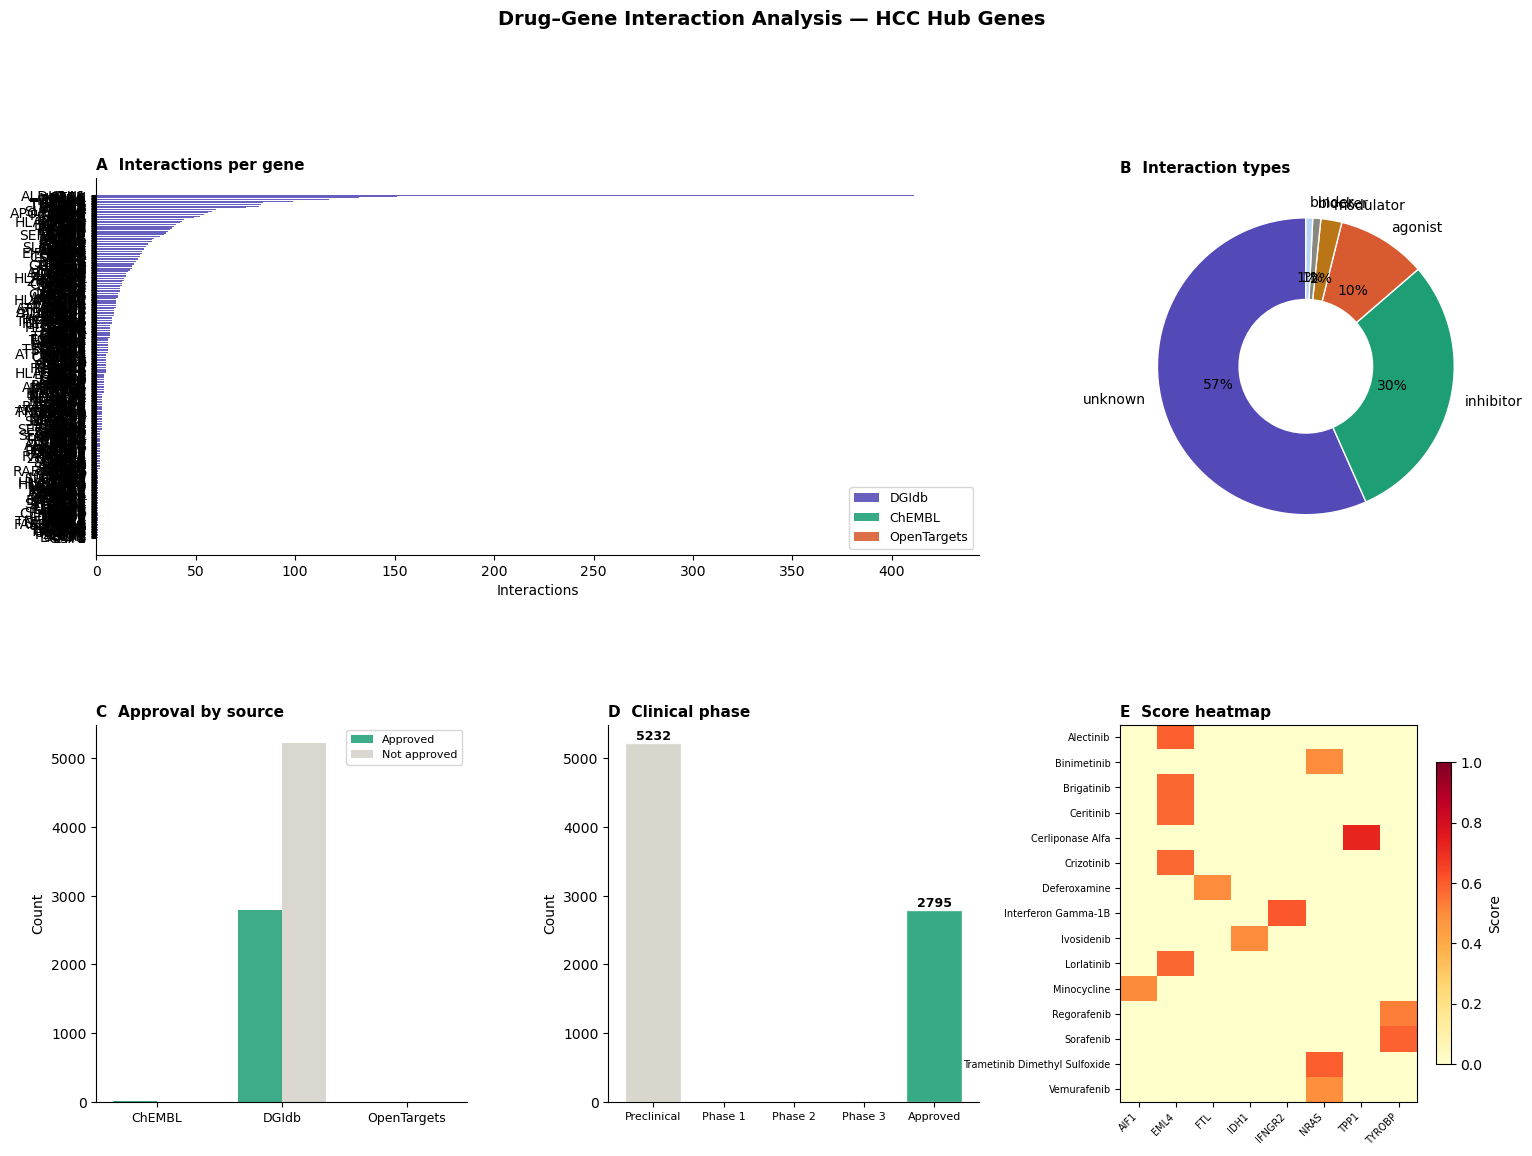

In [9]:
plot_dgi_dashboard(dgi_df, FIGURES_DIR)

## 5 · Export GNN-ready edge list

In [10]:
gnn_df = build_gnn_edge_list(dgi_df, hub_score_map, surv_genes, TABLES_DIR)

Saved: dgi_edges_gnn.csv
  Edges  : 8027
  Genes  : 547
  Drugs  : 4978
  → Ready for notebook P4 (GNN)
